In [198]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# ※ naver openAPI를 활용하여 네이버 지식인 "전주여행"과 "경주여행"을 검색(re?) -> 명사만 추출 -> 빈도분석(데이터프레임) -> 빈도 시각화(워드클라우드, nltk.Text 객체 활용) -> Word2Vec

# 1. 네이버 open API를 활용하여 검색 추출
- 검색어, no, title, link, description, title + ' ' + description(total_text)

## 키워드 별 지식인 검색 결과 제목, 내용 추출

In [97]:
# pip install python-dotenv
# pip install python-decouple
import os
os.getcwd() # 현재 작업 디렉토리

'C:\\ai_x\\source\\07_자연어처리'

In [98]:
%ls .env

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: 3664-591E

 C:\ai_x\source\07_자연어처리 디렉터리

2025-06-18  오후 05:40               364 .env
               1개 파일                 364 바이트
               0개 디렉터리  106,005,270,528 바이트 남음


In [99]:
import os
import sys
import dotenv
import urllib.request
import json
target = input('검색할 검색어 : ')
dotenv.load_dotenv()
client_id = os.getenv('Client_ID')
client_secret = os.getenv('Client_Secret')
encText = urllib.parse.quote(target)
start = 1

data_list = []
for _ in range(4) :
    url = f"https://openapi.naver.com/v1/search/kin?query={encText}&display=100&start={start}"
    request = urllib.request.Request(url)
    request.add_header("X-Naver-Client-Id",client_id)
    request.add_header("X-Naver-Client-Secret",client_secret)
    response = urllib.request.urlopen(request)
    rescode = response.getcode()
    if(rescode==200):
        response_body = response.read()
    #     print(response_body.decode('utf-8')) json형태 str
        data = json.loads(response_body.decode('utf-8'))
    #     print(data.get('items')) # list => 각 요소별로 딕셔너리 => dict.get('title'), dict.get('description')을 사용해서 문장별로 gj_data에 append
        for idx, val in enumerate(data.get('items')) :
#             print(val) # title link description
            if start == 1 :
                no = idx
            else : 
                no = (start*100) + idx
    #         print(val.get('description'))
            data_list.append([target, no, val.get('title').replace('<b>','').replace('</b>',''),val.get('link'),val.get('description').replace('<b>','').replace('</b>',''),val.get('title').replace('<b>','').replace('</b>','') + ' ' +val.get('description').replace('<b>','').replace('</b>','')])
    else:
        print("Error Code:" + rescode)
data_list
# 위 내용을 토대로하여 '검색어_data.txt' 파일에 total_text 저장하는 함수 생성

검색할 검색어 : 경주여행


[['경주여행',
  0,
  '추석에 경주 여행',
  'https://kin.naver.com/qna/detail.naver?d1id=9&dirId=90111&docId=474844021&qb=6rK97KO87Jes7ZaJ&enc=utf8',
  '추석에 경주 여행 가는거 어떻게 생각하시나요? 서울에서 버스를 타고 갈 경우, 버스가 버스전용 차선에서 운행하나요?... 질문하신 [추석 경주여행] 관련 답변 드리도록 하겠습니다. 첨성대, 석굴암, 불국사 등 유적지는 연중무휴로... ',
  '추석에 경주 여행 추석에 경주 여행 가는거 어떻게 생각하시나요? 서울에서 버스를 타고 갈 경우, 버스가 버스전용 차선에서 운행하나요?... 질문하신 [추석 경주여행] 관련 답변 드리도록 하겠습니다. 첨성대, 석굴암, 불국사 등 유적지는 연중무휴로... '],
 ['경주여행',
  1,
  '1박2일 경주 여행 일정 짜주세요',
  'https://kin.naver.com/qna/detail.naver?d1id=9&dirId=90111&docId=484345851&qb=6rK97KO87Jes7ZaJ&enc=utf8',
  "1박2일 경주 여행 일정 짜주세요 질문자님, 경주에서의 1박 2일 여행을 계획 중이시군요! 특히 '소록스테이'에서의... 아래에 경주 여행 일정을 간략히 정리해 드릴게요. 1박 2일 경주 여행 일정 Day 1: 감성 가득한 경주 탐방 10:30... ",
  "1박2일 경주 여행 일정 짜주세요 1박2일 경주 여행 일정 짜주세요 질문자님, 경주에서의 1박 2일 여행을 계획 중이시군요! 특히 '소록스테이'에서의... 아래에 경주 여행 일정을 간략히 정리해 드릴게요. 1박 2일 경주 여행 일정 Day 1: 감성 가득한 경주 탐방 10:30... "],
 ['경주여행',
  2,
  '어머니랑 1박2일 경주여행',
  'https://kin.naver.com/qna/detail.naver?d1id=9&dirId=9011403&docId=484291784&qb=6

In [199]:
def data_extract() :
    '''실행시키면 검색어를 입력하고
    검색어_data.txt파일에 total_text 저장하고 list를 return 함수입니다.
    backup을 위해 backup폴더를 자동 생성합니다.
    이후 데이터프레임 또한 해당 backup폴더에 backup시킵니다.'''
    import os
    import sys
    import dotenv
    import urllib.request
    import json
    import pandas as pd
    target = input('검색할 검색어 : ')
    dotenv.load_dotenv()
    client_id = os.getenv('Client_ID')
    client_secret = os.getenv('Client_Secret')
    encText = urllib.parse.quote(target)
    start = 1
     # JSON 결과
    # url = "https://openapi.naver.com/v1/search/blog.xml?query=" + encText # XML 결과
    dataframe = pd.DataFrame()
    data_list = []
    for _ in range(4) :
        url = f"https://openapi.naver.com/v1/search/kin?query={encText}&display=100&start={start}"
        request = urllib.request.Request(url)
        request.add_header("X-Naver-Client-Id",client_id)
        request.add_header("X-Naver-Client-Secret",client_secret)
        response = urllib.request.urlopen(request)
        rescode = response.getcode()
        if(rescode==200):
            response_body = response.read()
        #     print(response_body.decode('utf-8')) json형태 str
            data = json.loads(response_body.decode('utf-8'))
        #     print(data.get('items')) # list => 각 요소별로 딕셔너리 => dict.get('title'), dict.get('description')을 사용해서 문장별로 gj_data에 append
            for val in data.get('items') :
        #         print(val.get('title'))
        #         print(val.get('description'))
                data_list.append([val.get('title').replace('<b>','').replace('</b>','') + ' ' +val.get('description').replace('<b>','').replace('</b>','')])
        else:
            print("Error Code:" + rescode)
        start +=1
        
    os.makedirs('backup',exist_ok=True)
    file_name = f'backup/{target}_data.txt'
    with open(file_name,encoding='utf-8',mode='w') as f :
        for line in data_list :
            f.write(line[0])
            f.write('\n')
    return data_list

In [200]:
gj_data = data_extract()
jj_data = data_extract()

검색할 검색어 : 서울PM현황
검색할 검색어 : 음료트랜드


In [102]:
print(gj_data,jj_data)

[['추석에 경주 여행 추석에 경주 여행 가는거 어떻게 생각하시나요? 서울에서 버스를 타고 갈 경우, 버스가 버스전용 차선에서 운행하나요?... 질문하신 [추석 경주여행] 관련 답변 드리도록 하겠습니다. 첨성대, 석굴암, 불국사 등 유적지는 연중무휴로... '], ["1박2일 경주 여행 일정 짜주세요 1박2일 경주 여행 일정 짜주세요 질문자님, 경주에서의 1박 2일 여행을 계획 중이시군요! 특히 '소록스테이'에서의... 아래에 경주 여행 일정을 간략히 정리해 드릴게요. 1박 2일 경주 여행 일정 Day 1: 감성 가득한 경주 탐방 10:30... "], ['어머니랑 1박2일 경주여행 이제 5월달 어버이날을 위해 어머니랑 경주 여행을 할려고합니다 ㅎㅎ 놀러갈데는 다 정했는데 펜션을... ㅠㅠ 안녕하세요~ 어버이날을 맞아 어머니와 함께 경주 여행을 계획 중이시군요. 특별한 시간을 보내시려는 마음이 느껴져서 더욱... '], ['경주 여행 5월6,7,8일 경주 여행을 가는데요 동궁과월지와 월정교 야경을 보고 싶은데 7일에 정상 운영 되나요? 휴무일이 따로 없어서 관람에 방해가 될정도로 날씨가 나쁜상황이 생겨서 통제를 하는 경우가 아니라면 관람이 가능하겠습니다... '], ['경주여행 30만원 경주 여행 2박3일 남자친구랑 가는데 숙소랑 ktx비는 다 냈고 제 개인적으로 30만원이면 부족할까요? 30만원으로 경주 여행을 계획하고 계신다면, 예산이 어떻게 집행되느냐에 따라 충분할 수도, 부족할 수도 있습니다.... '], ['경주 여행 맛집 경주 여행 가고싶은데 맛집 추천 부탁드려뇨 경주 여행 가이드: 교통편, 맛집, 볼거리까지 모두 알려줄게요! 경주는 한국의 역사와 문화가 살아 숨 쉬는 도시로, 여행하기 좋은 명소가 많아요! 2025년 봄, 경주로 떠나고... '], ['경주 여행을 가는데 갈만한 곳 추천좀 경주 여행을 가는데 갈만한 곳 추천좀 해주세요 경주 여행 추천지 입니다 경주월드 국립 경주 박물관 황리단길 첨성대 불국사 엑스포 공원 등등 입니다'], ['2월 

## 품사태깅

In [201]:
# 품사 태깅
from mecab import MeCab
mecab = MeCab()
sample = ''
sample_tag_list = []
for data in gj_data :
    sample += data[0]
sample_tag = mecab.pos(sample)

In [202]:
pd.DataFrame(sample_tag).head(5)

,0,1
0,미세먼지,NNP
1,ㅡ서울,UNKNOWN
2,.,SF
3,..,SY
4,서울,NNP


## 품사태깅 백업

In [167]:
pd.DataFrame(sample_tag).to_csv('backup/sample.csv',index=False)

## 품사를 통해 명사를 추출

In [169]:
dat = pd.read_csv('backup/sample.csv')
[data[0] for data in dat.to_numpy().tolist() if data[1].startswith('N')]

['추석',
 '경주',
 '여행',
 '추석',
 '경주',
 '여행',
 '거',
 '생각',
 '서울',
 '버스',
 '경우',
 '버스',
 '버스',
 '전용',
 '차선',
 '운행',
 '질문',
 '추석',
 '경주',
 '여행',
 '관련',
 '답변',
 '첨성대',
 '석굴암',
 '불국사',
 '등',
 '유적지',
 '연중무휴',
 '박',
 '일',
 '경주',
 '여행',
 '일정',
 '박',
 '일',
 '경주',
 '여행',
 '일정',
 '문자',
 '경주',
 '박',
 '일',
 '여행',
 '계획',
 '중',
 '소록',
 '스테이',
 '아래',
 '경주',
 '여행',
 '일정',
 '정리',
 '박',
 '일',
 '경주',
 '여행',
 '일정',
 '감성',
 '경주',
 '어머니',
 '박',
 '일',
 '경주',
 '여행',
 '월',
 '달',
 '어버이날',
 '어머니',
 '경주',
 '여행',
 '데',
 '펜션',
 '안녕',
 '어버이날',
 '어머니',
 '경주',
 '여행',
 '계획',
 '중',
 '특별',
 '시간',
 '마음',
 '경주',
 '여행',
 '월',
 '일',
 '경주',
 '여행',
 '동궁',
 '월지',
 '월',
 '정교',
 '야경',
 '일',
 '정상',
 '운영',
 '휴무일',
 '관람',
 '방해',
 '정도',
 '날씨',
 '상황',
 '통제',
 '경우',
 '관람',
 '가능',
 '경주',
 '여행',
 '만',
 '원',
 '경주',
 '여행',
 '박',
 '일',
 '남자',
 '친구',
 '숙소',
 '비',
 '제',
 '개인',
 '만',
 '원',
 '부족',
 '만',
 '원',
 '경주',
 '여행',
 '계획',
 '예산',
 '집행',
 '수',
 '부족',
 '수',
 '경주',
 '여행',
 '맛집',
 '경주',
 '여행',
 '맛집',
 '추천',
 '부탁',
 '경주',
 '여행',
 '가이드',
 '교통편',
 

# 2. 검색 결과 nouns 추출

In [103]:
# 검색결과 백업 결과물을 가져오는 방법
def data_open(filepath ='backup/경주여행_data.txt') :
    ' 변수로 filepath를 받아 txt 파일을 읽어 리스트로 반환하는 기능'
    data_test=[]
    with open(filepath,mode='r', encoding='utf-8') as f :
        for i in f.readlines() :
            data_test.append(i.split('\n'))
    return data_test

In [104]:
data_open('backup/전주여행_data.txt')

[['전주 가볼만한곳 추천 받아요 ... 추억의 7080 #다양한체험 #7080감성 #추억여행 #테마박물관 #유익한시간 2. [전북] 전북투어패스 통합이용권 #전북핫플 #여러여행지 #다양한체험 #카페이용추가 #전주여행필수 편안하고 즐거운 날이 되시길 바라겠습니다. 감사합니다 :)',
  ''],
 ['전주여행갈려고하는데요! 전주여행을 갈려고하는데요!아는사람과 갈려고하는데 호텔은 좋은가격에 정했고~ 음..2박3일여행인데 얼마정도갖고가면좋을까요?그리고 맛집같은거 카페같은거 추천해주세요! 안녕하세요~ 전주 여행 계획 중이시네요! 한옥마을 근처... ',
  ''],
 ['전주 1박 2일 여행 관련 질문~ ... 전주 여행을 계획하고 계시다니 정말 좋은 선택을 하셨네요. 전주는 한옥마을과 함께 멋진 자연경관, 맛있는 음식이 가득한 동네이니 정말 즐거운 시간을 보낼 수 있을 거예요. 우선 한옥마을 근처에서 가볼 수 있는 장소로는... ',
  ''],
 ['중2 여학생 친구와 전주여행 안녕하세요!중 2(15살)여학생입니다.친한친구와 둘이서 전주 여행을 가기로 했는데 어디로 가야할지를 몰라서 너무 막막합니다ㅜ저희 둘다 일본 애니를 너무 좋아하는데전주에 오타쿠들이 갈만할 곳 있을까요??제발 알려주세요ㅜㅜ... ',
  ''],
 ['부모닝 모시고 전주여행 부모님 모시고 전주여행가려는데 명소, 식당 추천부탁드립니다 ---------------------------------------------------------------------------------------------------- 전주는 한옥마을로 유명한 완산구가 있으며, 덕진구 또한 멋진 추억을 가진 장소가 많이... ',
  ''],
 ['2박3일 전주여행 이번주 토~월 2박3일 여자친구와 전주여행을 가는데 여행경로 좀 알려주세요~~ 토요일엔 비가 온다고 하는데 실내데이트 가능한곳도 알려주시면 감사하겠습니다 ㅎㅎ 숙소는 전주한옥마을 근처에 잡았습니다. 토: 한옥마을 구경 후... ',
  ''],
 ['전주 

In [203]:
# 필요 라이브러리 -> konlpy 활용 or mecab 활용
from mecab import MeCab

In [204]:
mecab = MeCab()
gj_sent = [' '.join(data) for data in gj_data]
jj_sent = [' '.join(data) for data in jj_data]
gj_word2vec = [mecab.nouns(sent) for sent in gj_sent]
jj_word2vec = [mecab.nouns(sent) for sent in jj_sent]
gj_nouns = mecab.nouns(' '.join(gj_sent))
jj_nouns = mecab.nouns(' '.join(jj_sent))

In [205]:
# gj_nouns, jj_nouns
gj_word2vec, jj_word2vec

([['미세먼지',
   '서울',
   '미세먼지',
   '현황',
   '년',
   '월',
   '일',
   '기준',
   '서울',
   '미세먼지',
   '농도',
   '정상',
   '수준',
   '미세먼지',
   '농도',
   '보통',
   '수준',
   '서울',
   '종합',
   '대기',
   '지수'],
  ['미국',
   '한국',
   '일본',
   '대기',
   '오염',
   '현황',
   '우리나라',
   '대기',
   '오염',
   '현황',
   '대기',
   '오염',
   '영향',
   '대기',
   '오염',
   '제어',
   '실내',
   '공기',
   '오염',
   '출처',
   '지구',
   '사랑',
   '인류',
   '사랑',
   '대기',
   '오염',
   '서울',
   '대기',
   '오염',
   '미세먼지',
   '연평균',
   '시간',
   '평균',
   '오존',
   '시간',
   '평균',
   '시간'],
  ['서울',
   '연기',
   '학원',
   '캐스팅',
   '현황',
   '확인',
   '수',
   '감사',
   '인',
   '스타',
   '그램',
   '주',
   '포인트',
   '컴퍼니',
   '트레이닝',
   '센터',
   '서울',
   '강남구',
   '논현로',
   '길',
   '호'],
  ['공통점',
   '차이점',
   '매연',
   '질소',
   '화합물',
   '일산',
   '탄소',
   '이산화',
   '탄소',
   '자동차',
   '수송',
   '부문',
   '대기',
   '오염',
   '물질',
   '천연가스',
   '버스',
   '보급',
   '현황',
   '서울',
   '부산',
   '대구',
   '인천',
   '광주',
   '대전',
   '울산',
   '경기',
   '충북',
   '전북',
   '경남

# 3. 추출한 명사들로 빈도 분석

## 3.1 빈도분석(데이터프레임)

In [206]:
# 필요 라이브러리 : pandas, defaultdict 활용
import pandas as pd
from collections import defaultdict

In [207]:
gj_dict = defaultdict(int)
jj_dict = defaultdict(int)

In [208]:
for data in gj_nouns :
    gj_dict[data] +=1
for data in jj_nouns :
    jj_dict[data] +=1

In [209]:
gj_series = pd.Series(gj_dict).sort_values(ascending=False)
jj_series = pd.Series(jj_dict).sort_values(ascending=False)
gj_series.to_csv('backup/경주여행_단어출현빈도수.csv')
jj_series.to_csv('backup/전주여행_단어출현빈도수.csv')

In [210]:
display(gj_series.head(3), jj_series.head(3))

서울    545
연기    429
학원    429
dtype: int64

박람회    1140
카페      784
커피      780
dtype: int64

## 3.2 빈도 시각화

### 3.2.1 워드 클라우드

In [211]:
# 필요 라이브러리 import
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [212]:
# 모양이 마음에 안들어서 수정
불용어 = {'경주','여행','경주여행','추천', '전주','전주여행'}
import cv2
gj_mask = cv2.imread('data/heart.jpg')
jj_mask = cv2.imread('data/korea-house-black-fill.png')
gj_mask.shape, jj_mask.shape

((1600, 1600, 3), (275, 556, 3))

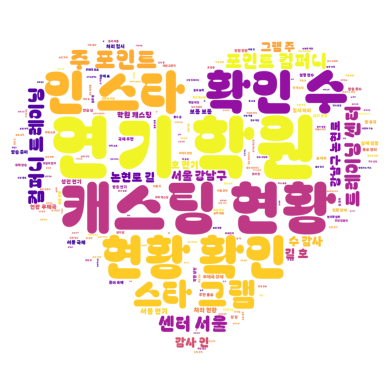

In [213]:
wordc_gj = WordCloud(
    font_path='font/Bagel_Fat_One/BagelFatOne-Regular.ttf',
    width = 400, 
    height= 300,
    background_color='white', # 배경색
    colormap='plasma',
    mask=gj_mask,
    stopwords=불용어,
)
wordc_gj.generate(' '.join(gj_nouns))
plt.imshow(wordc_gj)
plt.axis('off')
plt.show()

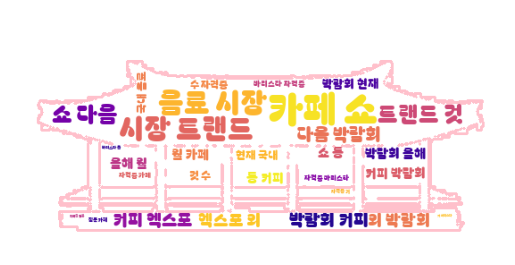

In [214]:
wordc_jj = WordCloud(
    font_path='font/Bagel_Fat_One/BagelFatOne-Regular.ttf',
    width = 400, 
    height= 300,
    background_color='white', # 배경색
    colormap='plasma',
    mask=jj_mask,
    stopwords=불용어,
    contour_color='pink', # mask의 외곽선을 그려줌
    contour_width=2
)
wordc_jj.generate(' '.join(jj_nouns))
plt.imshow(wordc_jj)
plt.axis('off')
plt.show()

### 3.2.2 nltk.Text 객체를 활용한 빈도수 시각화

In [215]:
# 필요 라이브러리 import
import nltk

In [216]:
gj_text = nltk.Text([noun for noun in gj_nouns if noun not in 불용어])
jj_text = nltk.Text([noun for noun in jj_nouns if noun not in 불용어])

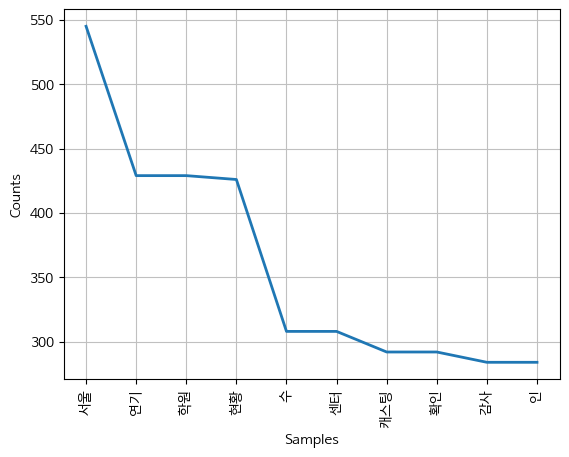

<Axes: xlabel='Samples', ylabel='Counts'>

In [217]:
# 1. 경주
plt.rc('font',family = 'Hancom Gothic')
gj_text.plot(10) # 그래프는 이쁜데 x,y라벨을 수정할 수 없음.

In [218]:
# Text.vocab().most_common() 함수를 이용해서 그래프 세부 조종

gj_x = [x for x,y in gj_text.vocab().most_common(15) if x not in ('경주','여행','경주여행','추천')]
gj_y = [y for x,y in gj_text.vocab().most_common(15) if x not in ('경주','여행','경주여행','추천')]

Text(0.5, 1.0, '경주여행')

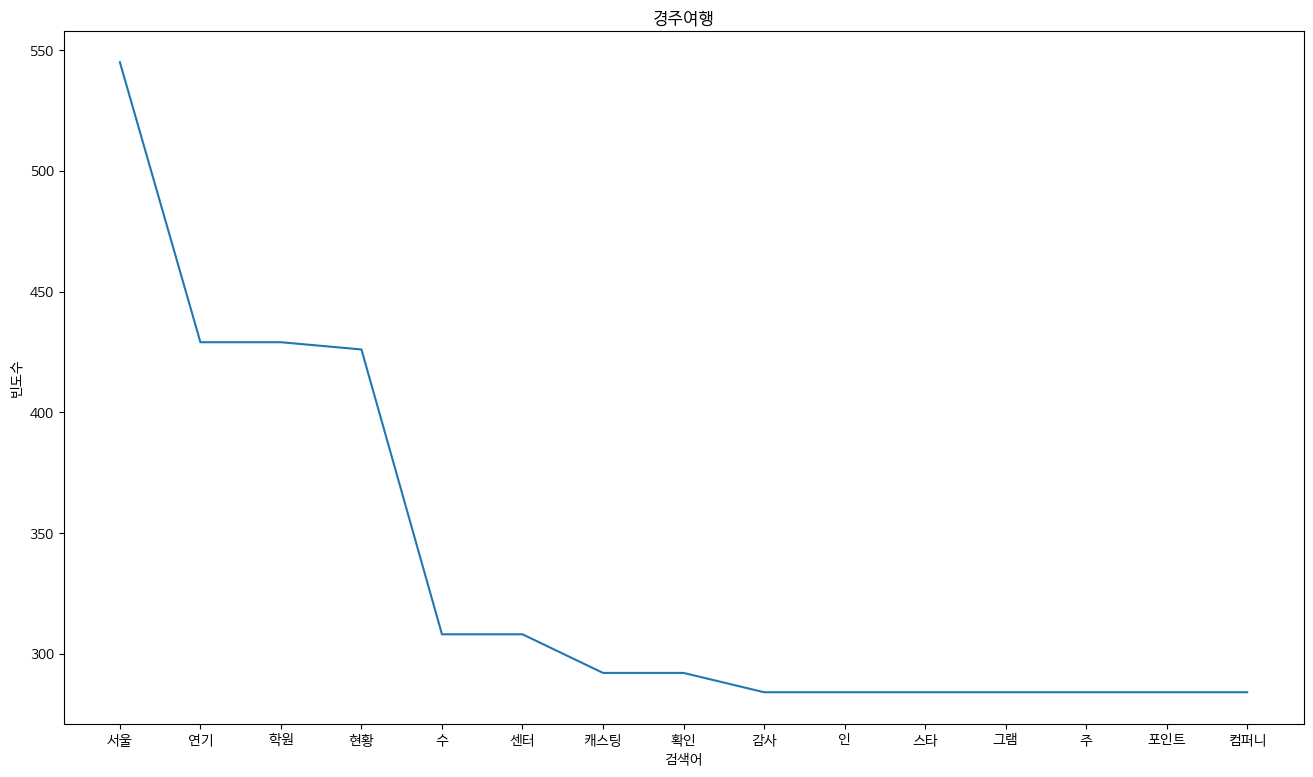

In [219]:
plt.figure(figsize=(16,9))
plt.plot(gj_x, gj_y)
plt.xlabel('검색어')
plt.ylabel('빈도수')
plt.title('경주여행')

Text(0.5, 1.0, '전주여행')

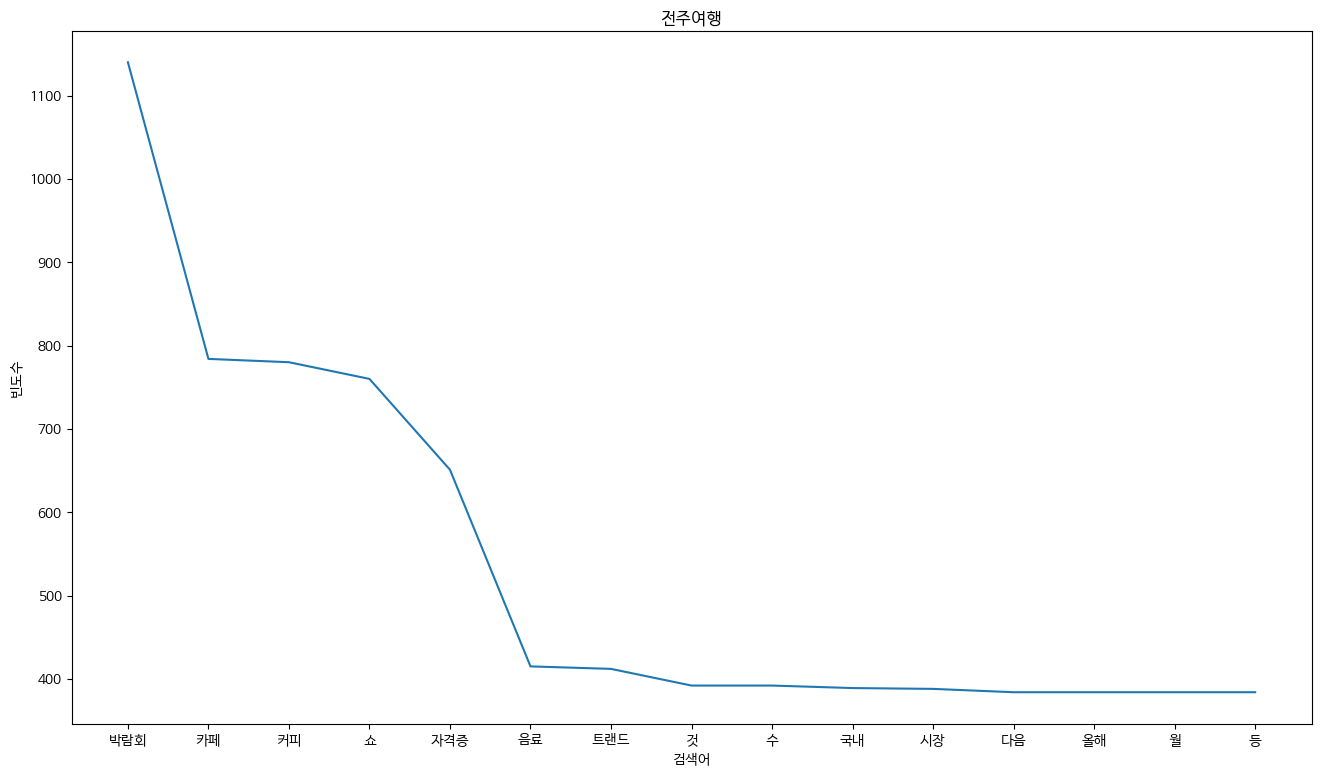

In [220]:
# Text.vocab().most_common() 함수를 이용해서 그래프 세부 조종
jj_x = [x for x,y in jj_text.vocab().most_common(15) if x not in ('전주','여행','전주여행','추천')]
jj_y = [y for x,y in jj_text.vocab().most_common(15) if x not in ('전주','여행','전주여행','추천')]
plt.figure(figsize=(16,9))
plt.plot(jj_x, jj_y)
plt.xlabel('검색어')
plt.ylabel('빈도수')
plt.title('전주여행')

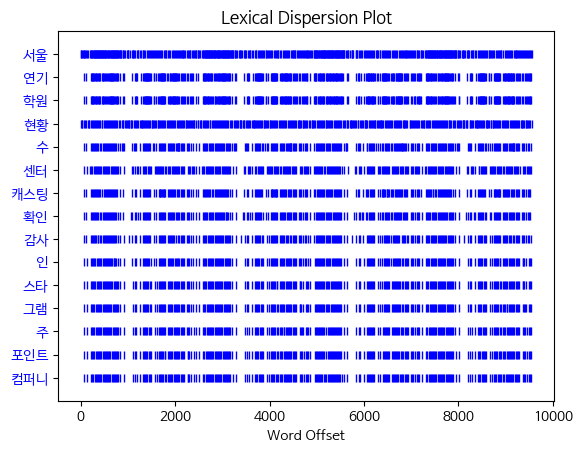

In [221]:
gj_text.dispersion_plot(gj_x)

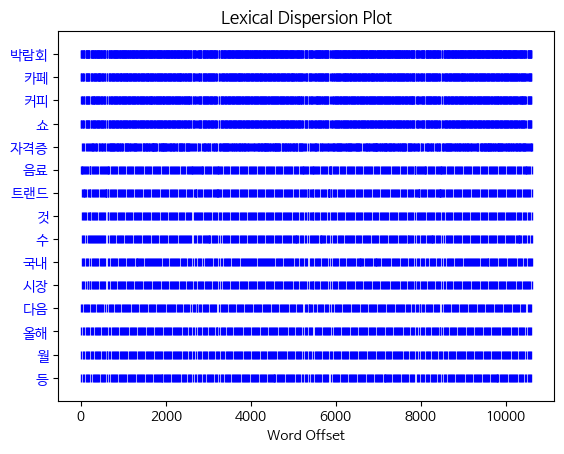

In [222]:
jj_text.dispersion_plot(jj_x)

# 4. Word2Vec

## 4.1 경주 연관성분석 모델

In [223]:
noun_list = []
for row in gj_word2vec :
    temp = []
    for noun in row :
        if len(noun) >= 2 :
            temp.append(noun)
    noun_list.append(temp)
noun_list

[['미세먼지',
  '서울',
  '미세먼지',
  '현황',
  '기준',
  '서울',
  '미세먼지',
  '농도',
  '정상',
  '수준',
  '미세먼지',
  '농도',
  '보통',
  '수준',
  '서울',
  '종합',
  '대기',
  '지수'],
 ['미국',
  '한국',
  '일본',
  '대기',
  '오염',
  '현황',
  '우리나라',
  '대기',
  '오염',
  '현황',
  '대기',
  '오염',
  '영향',
  '대기',
  '오염',
  '제어',
  '실내',
  '공기',
  '오염',
  '출처',
  '지구',
  '사랑',
  '인류',
  '사랑',
  '대기',
  '오염',
  '서울',
  '대기',
  '오염',
  '미세먼지',
  '연평균',
  '시간',
  '평균',
  '오존',
  '시간',
  '평균',
  '시간'],
 ['서울',
  '연기',
  '학원',
  '캐스팅',
  '현황',
  '확인',
  '감사',
  '스타',
  '그램',
  '포인트',
  '컴퍼니',
  '트레이닝',
  '센터',
  '서울',
  '강남구',
  '논현로'],
 ['공통점',
  '차이점',
  '매연',
  '질소',
  '화합물',
  '일산',
  '탄소',
  '이산화',
  '탄소',
  '자동차',
  '수송',
  '부문',
  '대기',
  '오염',
  '물질',
  '천연가스',
  '버스',
  '보급',
  '현황',
  '서울',
  '부산',
  '대구',
  '인천',
  '광주',
  '대전',
  '울산',
  '경기',
  '충북',
  '전북',
  '경남',
  '천연가스',
  '충전'],
 ['서울',
  '연기',
  '학원',
  '캐스팅',
  '현황',
  '확인',
  '감사',
  '스타',
  '그램',
  '포인트',
  '컴퍼니',
  '트레이닝',
  '센터',
  '서울',
  '강남구',
  '논현로'],
 ['차이점'

In [224]:
from gensim.models import Word2Vec
gj_model = Word2Vec(noun_list, # 학습 데이터 2차원
                window = 10, # 각 단어의 앞뒤 10개 단어를 학습 컨텐츠로 사용
                 min_count = 5, # 학습 데이터에서 2회 이상 등장 시 학습.
                 workers = -1, # 병렬처리 코어core 수. -1 : 모든 가용 코어 사용
                )

## 4.2 전주 연관성분석 모델

In [225]:
noun_list2 = []
for row in jj_word2vec :
    temp = []
    for noun in row :
        if len(noun) >= 2 :
            temp.append(noun)
    noun_list2.append(temp)
noun_list2

[['수제',
  '케이크',
  '음료',
  '디저트',
  '카페',
  '다음',
  '박람회',
  '커피',
  '엑스포',
  '박람회',
  '올해',
  '카페',
  '커피',
  '박람회',
  '현재',
  '국내',
  '음료',
  '시장',
  '트랜드',
  '자격증'],
 ['국외',
  '식음료',
  '개발',
  '실기',
  '카페',
  '다음',
  '박람회',
  '커피',
  '엑스포',
  '박람회',
  '올해',
  '카페',
  '커피',
  '박람회',
  '현재',
  '국내',
  '음료',
  '시장',
  '트랜드',
  '자격증'],
 ['부천',
  '바리스타',
  '학원',
  '국비',
  '지원',
  '추천',
  '카페',
  '다음',
  '박람회',
  '커피',
  '엑스포',
  '박람회',
  '올해',
  '카페',
  '커피',
  '박람회',
  '현재',
  '국내',
  '음료',
  '시장',
  '트랜드',
  '자격증'],
 ['트랜드',
  '건강',
  '위주',
  '트랜드',
  '건강',
  '위주',
  '코카',
  '콜라',
  '회사',
  '확률',
  '코카',
  '콜라',
  '대형',
  '음료',
  '회사',
  '확률',
  '생각',
  '다음',
  '이유',
  '때문',
  '첫째',
  '코카',
  '콜라'],
 ['카페',
  '다음',
  '박람회',
  '커피',
  '엑스포',
  '박람회',
  '올해',
  '카페',
  '커피',
  '박람회',
  '현재',
  '국내',
  '음료',
  '시장',
  '트랜드',
  '자격증'],
 ['한국',
  '검정',
  '평가',
  '자격증',
  '취득',
  '카페',
  '다음',
  '박람회',
  '커피',
  '엑스포',
  '박람회',
  '올해',
  '카페',
  '커피',
  '박람회',
  '현재',
  '국내',
  '음료',
  '시장',

In [226]:
jj_model = Word2Vec(noun_list2, # 학습 데이터 2차원
                window = 10, # 각 단어의 앞뒤 10개 단어를 학습 컨텐츠로 사용
                 min_count = 5, # 학습 데이터에서 2회 이상 등장 시 학습.
                 workers = -1, # 병렬처리 코어core 수. -1 : 모든 가용 코어 사용
                )

In [227]:
gj_model.wv.most_similar('추천')

[('강원', 0.21165511012077332),
 ('서울시', 0.20711486041545868),
 ('과정', 0.20594538748264313),
 ('상세', 0.19613032042980194),
 ('진행', 0.19099904596805573),
 ('내공', 0.18406276404857635),
 ('어디', 0.17293184995651245),
 ('문의', 0.17277595400810242),
 ('미국', 0.15878427028656006),
 ('수준', 0.15611957013607025)]

In [229]:
jj_model.wv.most_similar('음료')

[('질문', 0.2529045641422272),
 ('렌즈', 0.20082910358905792),
 ('차이점', 0.1957002431154251),
 ('기간', 0.17530226707458496),
 ('커피', 0.17018885910511017),
 ('바리스타', 0.15016482770442963),
 ('위주', 0.14516256749629974),
 ('트랜드', 0.13887980580329895),
 ('시험', 0.10852648317813873),
 ('때문', 0.1062556579709053)]

## 4.3 통합모델

In [230]:
# 경주, 전주 통합 모델
total_word2vec = []
total_word2vec.extend(noun_list)
total_word2vec.extend(noun_list2)
total_model = Word2Vec(total_word2vec,
                       window=10,
                       workers = -1
                      )

In [232]:
total_model.wv.most_similar('음료')

[('바리스타', 0.2853359878063202),
 ('조회', 0.23983338475227356),
 ('버스', 0.21086272597312927),
 ('사용', 0.20956943929195404),
 ('송장', 0.20667847990989685),
 ('이산화', 0.2057950645685196),
 ('커피', 0.19912061095237732),
 ('창업', 0.190286785364151),
 ('전문학교', 0.18201813101768494),
 ('보급', 0.17296291887760162)]

In [131]:
import psutil
psutil.virtual_memory() # 메모리 영역 체크

svmem(total=16948908032, available=9154498560, percent=46.0, used=7794409472, free=9154498560)

[['전주',
  '만',
  '곳',
  '추천',
  '추억',
  '다양',
  '체험',
  '감성',
  '추억',
  '여행',
  '테마',
  '박물관',
  '유익',
  '시간',
  '전북',
  '전북',
  '투어',
  '패스',
  '통합',
  '용권',
  '전북',
  '핫',
  '플',
  '여행지',
  '다양',
  '체험',
  '카페이',
  '용추',
  '전주',
  '여행',
  '필수',
  '편안',
  '날',
  '감사'],
 ['전주',
  '여행',
  '전주',
  '여행',
  '사람',
  '호텔',
  '가격',
  '박',
  '일',
  '여행',
  '얼마',
  '정도',
  '맛집',
  '거',
  '카페',
  '거',
  '추천',
  '전주',
  '여행',
  '계획',
  '중',
  '한옥',
  '마을',
  '근처'],
 ['전주',
  '박',
  '일',
  '여행',
  '관련',
  '질문',
  '전주',
  '여행',
  '계획',
  '선택',
  '전',
  '한옥마을',
  '자연',
  '경관',
  '음식',
  '동네',
  '시간',
  '수',
  '거',
  '한옥',
  '마을',
  '근처',
  '수',
  '장소'],
 ['중',
  '여학생',
  '친구',
  '전주',
  '여행',
  '안녕',
  '중',
  '살',
  '여학생',
  '친구',
  '둘',
  '전주',
  '여행',
  '어디',
  '둘',
  '일본',
  '애니',
  '전주',
  '오타쿠',
  '갈만',
  '곳'],
 ['부모',
  '닝',
  '전주',
  '여행',
  '부모',
  '전주',
  '여행',
  '명소',
  '식당',
  '추천',
  '부탁',
  '전주',
  '한옥마을',
  '완산구',
  '덕진구',
  '추억',
  '장소'],
 ['박',
  '일',
  '전주',
  '여행',
  '이번',
  '주',
 